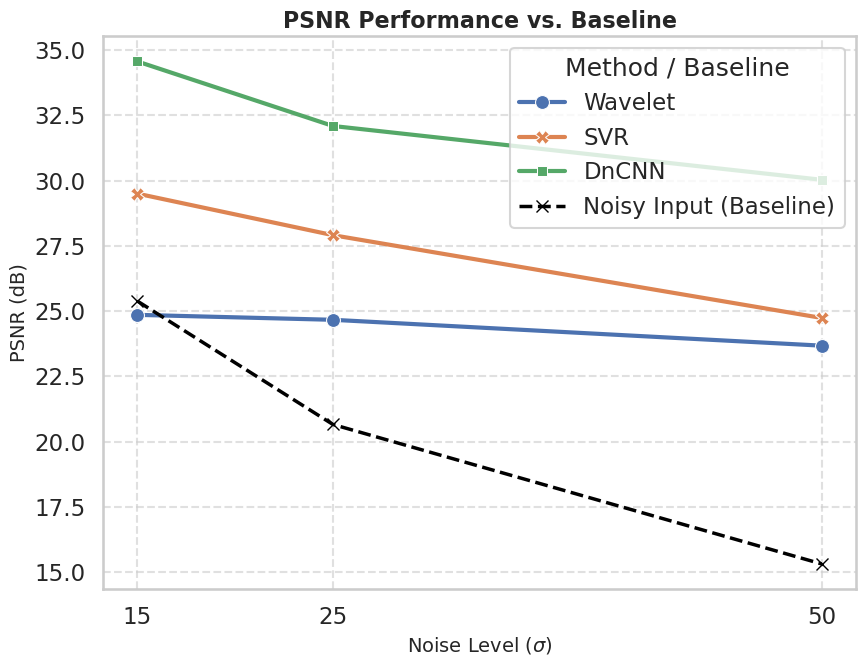

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 准备数据
data = {
    'Method': ['Wavelet', 'Wavelet', 'Wavelet', 
               'SVR', 'SVR', 'SVR', 
               'DnCNN', 'DnCNN', 'DnCNN'],
    'Noise Sigma': [15, 25, 50, 
                    15, 25, 50, 
                    15, 25, 50],
    'Noisy PSNR': [24.80, 20.66, 15.32, 
                   24.81, 20.67, 15.32, 
                   26.55, 20.66, 15.33],
    'Denoised PSNR': [24.86, 24.67, 23.68, 
                      29.50, 27.91, 24.74, 
                      34.56, 32.09, 30.03],
    'SSIM': [0.719, 0.713, 0.686, 
             0.651, 0.596, 0.433, 
             0.901, 0.853, 0.789]
}

df = pd.DataFrame(data)

# 2. 提取基准线数据 (计算每个噪声等级下的平均 Noisy PSNR，以防数据有微小波动)
baseline_df = df.groupby('Noise Sigma')['Noisy PSNR'].mean().reset_index()

# 设置风格
sns.set(style="whitegrid", context="talk")

# --- 开始绘图 ---
plt.figure(figsize=(9, 7))

# A. 画各方法的去噪性能 (实线)
sns.lineplot(data=df, x='Noise Sigma', y='Denoised PSNR', 
             hue='Method', style='Method', 
             markers=True, dashes=False, linewidth=3, markersize=10)

# B. 画基准线 (Noisy Input - 黑色虚线)
plt.plot(baseline_df['Noise Sigma'], baseline_df['Noisy PSNR'], 
         color='black', linestyle='--', linewidth=2.5, marker='x', 
         label='Noisy Input (Baseline)')

# C. 图表美化
plt.title('PSNR Performance vs. Baseline', fontweight='bold', fontsize=16)
plt.ylabel('PSNR (dB)', fontsize=14)
plt.xlabel(r'Noise Level ($\sigma$)', fontsize=14)
plt.xticks([15, 25, 50])

# D. 调整图例 (Legend)
plt.legend(title='Method / Baseline', loc='best', frameon=True)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('comparison_PSNR.png', dpi=300)
plt.show()

/tmp/ipykernel_1801/1734741441.py:39: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.lineplot(data=df_methods, x='Noise Sigma', y='SSIM',


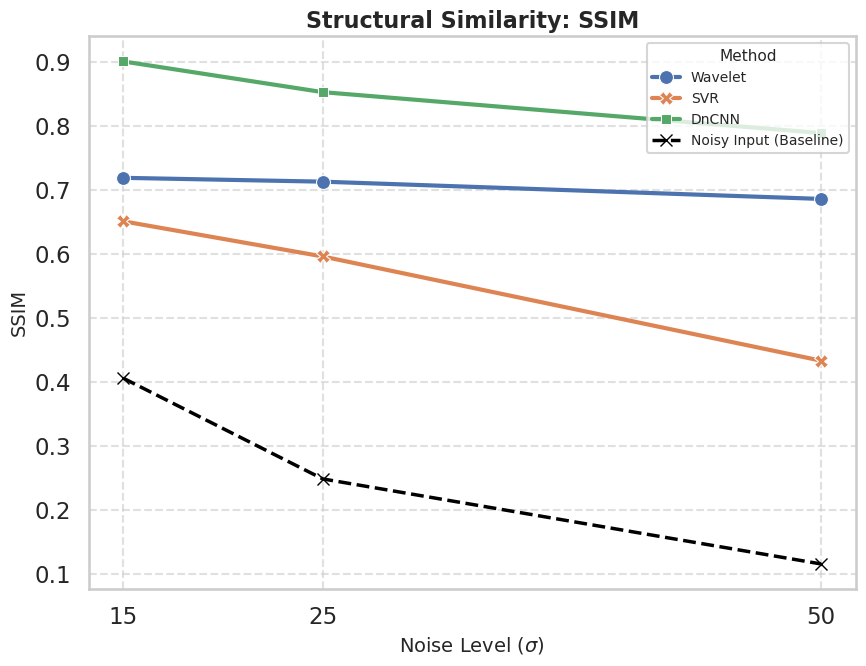

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 准备数据 (仅保留 SSIM)
# ==========================================

# A. 各个去噪方法的数据
method_data = {
    'Method': ['Wavelet', 'Wavelet', 'Wavelet', 
               'SVR', 'SVR', 'SVR', 
               'DnCNN', 'DnCNN', 'DnCNN'],
    'Noise Sigma': [15, 25, 50, 
                    15, 25, 50, 
                    15, 25, 50],
    'SSIM': [0.719, 0.713, 0.686, 
             0.651, 0.596, 0.433, 
             0.901, 0.853, 0.789]
}
df_methods = pd.DataFrame(method_data)

# B. 基准线数据 (Noisy Input Baseline)
baseline_sigma = [15, 25, 50]
baseline_ssim  = [0.4055, 0.2481, 0.1151]

# ==========================================
# 2. 设置绘图风格
# ==========================================
sns.set(style="whitegrid", context="talk")
palette = sns.color_palette("deep") 

# ==========================================
# 3. 绘制 SSIM 对比图
# ==========================================
plt.figure(figsize=(9, 7))

# A. 画去噪方法 (实线)
sns.lineplot(data=df_methods, x='Noise Sigma', y='SSIM', 
             hue='Method', style='Method', palette=palette,
             markers=True, dashes=False, linewidth=3, markersize=10)

# B. 画基准线 (黑色虚线 - Noisy Input)
plt.plot(baseline_sigma, baseline_ssim, 
         color='black', linestyle='--', linewidth=2.5, marker='x', markersize=8,
         label='Noisy Input (Baseline)')

# C. 格式化图表
plt.title('Structural Similarity: SSIM', fontweight='bold', fontsize=16)
plt.ylabel('SSIM', fontsize=14)
plt.xlabel(r'Noise Level ($\sigma$)', fontsize=14)
plt.xticks([15, 25, 50]) # 强制只显示这三个刻度
plt.legend(title='Method', loc='upper right', fontsize=10, title_fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# 保存并显示

plt.tight_layout()
plt.savefig('comparison_ssim.png', dpi=300)
plt.show()